In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Fix dependency conflicts by avoiding strict version pinning that clashes with Kaggle's environment
# We install albumentations and ultralytics without forcing numpy downgrades
!pip install -q "albumentations>=1.3.0" ultralytics --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.4 MB/s eta 0:00:0000:01


In [4]:
# ============================================================
# BLOCK 1 — IMPORTS, CONFIG, SEEDING (AUGMENTATION READY)
# ============================================================

import os
import json
import math
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import GroupKFold
from tqdm.auto import tqdm
import albumentations as A  # The industry standard for CV augmentation

# ---------------- CONFIG ----------------
CFG = {
    "input_root": Path("/kaggle/input/face-sideview-kp/train"),
    "coco_json": Path("/kaggle/input/face-sideview-kp/train/_annotations.coco.json"),
    "yolo_weights": Path("/kaggle/input/yolov11n-seg-weights/pytorch/default/1/yolo11n-seg.pt"),

    "work_root": Path("/kaggle/working/final_kp_aug"),
    "img_size": 512,
    "hm_size": 64,    # Matches model output stride
    "num_kpts": 26,

    "batch_size": 32,
    "epochs": 30,     # Increased epochs because augmentation makes learning harder but better
    "lr": 3e-4,
    "weight_decay": 1e-5,

    "seed": 42,
    "folds": 5,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

CFG["work_root"].mkdir(parents=True, exist_ok=True)

# ---------------- AUGMENTATION PIPELINE ----------------
# We define two pipelines: Train (Heavy Augmentation) and Val (No Augmentation)

train_aug = A.Compose([
    # 1. Geometric Variations (The most important for keypoints)
    A.Rotate(limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    
    # 2. Pixel-level Variations (Simulating camera quality)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    
    # 3. Cutout / CoarseDropout (Forces model to not rely on a single feature)
    # This randomly blacks out small squares. If the eye is hidden, model must infer from nose/chin.
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, min_holes=1, p=0.3),

], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Validation pipeline is just identity (we might add resizing here if not done elsewhere, 
# but our dataset handles resizing manually for consistency)
val_aug = A.Compose([], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))


# ---------------- SEEDING ----------------
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])

print("Device:", CFG["device"])
print("Augmentation Pipeline: READY")

Device: cuda
Augmentation Pipeline: READY


/tmp/ipykernel_47/973352548.py:51: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_47/973352548.py:52: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
/tmp/ipykernel_47/973352548.py:57: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipykernel_47/973352548.py:61: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32,

In [5]:
# ============================================================
# BLOCK 2 — ROBUST COCO LOADING & HYGIENE
# ============================================================

# Load COCO
with open(CFG["coco_json"], "r") as f:
    coco = json.load(f)

images_info = {im["id"]: im for im in coco["images"]}
anns_by_image = defaultdict(list)

# 1. Filter Annotations
valid_anns = 0
dropped_anns = 0

for ann in coco["annotations"]:
    # Check 1: Must have keypoints
    if "keypoints" not in ann or not ann["keypoints"]:
        dropped_anns += 1
        continue
        
    # Check 2: Calculate Visibility
    # COCO format: [x, y, v, x, y, v...]
    kps = ann["keypoints"]
    visible_count = sum(1 for v in kps[2::3] if v > 0)
    
    # [ML Concept] Hard Thresholding
    # If fewer than 3 keypoints are visible, the geometric constraint is too weak.
    # The model will likely hallucinate the rest. We drop these.
    if visible_count < 3:
        dropped_anns += 1
        continue

    anns_by_image[ann["image_id"]].append(ann)
    valid_anns += 1

print(f"Data Hygiene Report:")
print(f"  - Total Images: {len(images_info)}")
print(f"  - Valid Annotations: {valid_anns}")
print(f"  - Dropped (Low Visibility/Empty): {dropped_anns}")

# Filter images to only those with valid annotations
valid_img_ids = [img_id for img_id, anns in anns_by_image.items() if len(anns) > 0]
images_info = {img_id: images_info[img_id] for img_id in valid_img_ids}

print(f"  - Usable Training Images: {len(images_info)}")

assert len(images_info) > 0, "All images were filtered out! Check criteria."

Data Hygiene Report:
  - Total Images: 514
  - Valid Annotations: 515
  - Dropped (Low Visibility/Empty): 0
  - Usable Training Images: 514


In [6]:
# ============================================================
# BLOCK 3 — ROBUST YOLO SEGMENTATION (FIXED)
# ============================================================

from ultralytics import YOLO

# 1. Robust Weight Loading with Fallback
# If your custom weights aren't attached, this will download standard weights instead of crashing.
if not CFG["yolo_weights"].exists():
    print(f"Custom weights not found at {CFG['yolo_weights']}")
    print("Downloading standard yolov8n-seg.pt as fallback...")
    yolo_model = YOLO("yolov8n-seg.pt")
else:
    yolo_model = YOLO(str(CFG["yolo_weights"]))

def segment_person_black_bg(img_bgr):
    """
    Isolates the largest person in the image and blacks out everything else.
    """
    h, w = img_bgr.shape[:2]
    
    # 1. Inference on CPU (Thread-safe for DataLoader)
    results = yolo_model(img_bgr, verbose=False, retina_masks=True, device='cpu')

    # 2. Fallback: If YOLO detects nothing, return original image.
    if not results or results[0].masks is None:
        return img_bgr

    r = results[0]
    masks = r.masks.data.cpu().numpy() # [N, H, W]
    cls = r.boxes.cls.cpu().numpy()    # [N]

    # 3. Filter for Class 0 (Person)
    person_indices = [i for i, c in enumerate(cls) if int(c) == 0]
    
    if not person_indices:
        return img_bgr

    # 4. Selection Heuristic: Largest Mask Area
    best_idx = max(person_indices, key=lambda i: masks[i].sum())
    mask = masks[best_idx]

    # 5. Resize Mask
    if mask.shape != (h, w):
        mask = cv2.resize((mask > 0.5).astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    else:
        mask = (mask > 0.5).astype(np.uint8)

    # 6. Apply Mask
    out = img_bgr.copy()
    out[mask == 0] = 0
    return out

def square_crop_safe(bbox, img_w, img_h, margin=0.2):
    """
    Expands a bounding box to be square, ensuring it stays within image bounds.
    """
    x, y, w, h = bbox
    cx, cy = x + w/2, y + h/2
    
    # Make square side equal to the largest dimension + margin
    side = max(w, h) * (1 + margin)
    
    x1 = int(cx - side/2)
    y1 = int(cy - side/2)
    x2 = int(cx + side/2)
    y2 = int(cy + side/2)
    
    return x1, y1, x2, y2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Custom weights not found at /kaggle/input/yolov11n-seg-weights/pytorch/default/1/yolo11n-seg.pt


In [7]:
# ============================================================
# BLOCK 4 — ROBUST CROP & RESIZE LOGIC
# ============================================================

def crop_and_resize(img_bgr, kps, bbox, out_size=512):
    """
    1. Segments person (black background).
    2. Crops square ROI around bbox.
    3. Resizes to out_size.
    4. Remaps keypoints to new coordinate system.
    """
    h, w = img_bgr.shape[:2]

    # 1. Segment (Remove Background Noise)
    img_seg = segment_person_black_bg(img_bgr)

    # 2. Calculate Crop Coordinates
    # We use a loose crop (margin=0.2) to ensure the chin/top of head isn't cut off
    x1, y1, x2, y2 = square_crop_safe(bbox, w, h, margin=0.2)

    # 3. Handle Out-of-Bounds (Padding)
    # If the face is at the edge of the image, our square crop might go outside.
    # We must pad the image with black pixels rather than crashing.
    pad_l = max(0, -x1)
    pad_t = max(0, -y1)
    pad_r = max(0, x2 - w)
    pad_b = max(0, y2 - h)

    if pad_l or pad_t or pad_r or pad_b:
        img_seg = cv2.copyMakeBorder(
            img_seg, pad_t, pad_b, pad_l, pad_r,
            cv2.BORDER_CONSTANT, value=(0, 0, 0)
        )
        x1 += pad_l
        y1 += pad_t
        x2 += pad_l
        y2 += pad_t

    # 4. Perform Crop
    crop = img_seg[y1:y2, x1:x2]

    # Robustness Check: If crop failed, return None
    if crop.size == 0:
        return None, None

    # 5. Resize to Target (512x512)
    ch, cw = crop.shape[:2]
    resized = cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_AREA)

    # 6. Remap Keypoints
    # The scale factor is (Target Size / Crop Size)
    sx = out_size / cw
    sy = out_size / ch

    kps_out = []
    
    # Iterate [x, y, v, x, y, v...]
    for i in range(0, len(kps), 3):
        x, y, v = kps[i], kps[i+1], kps[i+2]
        
        if v == 0:
            kps_out.append([0, 0, 0])
            continue

        # Math: (Original - Crop_Start + Padding) * Scale
        xr = (x + pad_l - x1) * sx
        yr = (y + pad_t - y1) * sy

        # Visibility Check: Is point still inside the 512x512 box?
        if 0 <= xr < out_size and 0 <= yr < out_size:
            kps_out.append([xr, yr, 1]) # Keep visibility = 1
        else:
            kps_out.append([0, 0, 0])   # Mark invisible

    # Return Grayscale Image (1 Channel) and Clean Keypoints
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    return gray, np.array(kps_out, dtype=np.float32)

In [8]:
# ============================================================
# BLOCK 5 — DATASET WITH HYBRID AUGMENTATION (FIXED)
# ============================================================

def gaussian_2d(width, height, cx, cy, sigma=1.0):
    """
    Generates a 2D Gaussian heatmap.
    (This function was missing in the original notebook)
    """
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    dist_sq = (x - cx) ** 2 + (y - cy) ** 2
    heatmap = np.exp(-dist_sq / (2 * sigma ** 2))
    return heatmap.astype(np.float32)

def build_heatmaps(kps, hm_size, sigma):
    """
    Generates 2D Gaussian Heatmaps from keypoints.
    kps: [N, 3] coordinates in Pixel Space (0-512)
    """
    num_kpts = kps.shape[0]
    hms = np.zeros((num_kpts, hm_size, hm_size), dtype=np.float32)
    
    # Scale factor from Image Size (512) to Heatmap Size (64)
    scale = hm_size / CFG["img_size"]

    for i in range(num_kpts):
        x, y, v = kps[i]
        if v == 0: continue
        
        # Scale coordinate to heatmap space
        cx, cy = x * scale, y * scale
        
        # Generate Gaussian
        hm = gaussian_2d(hm_size, hm_size, cx, cy, sigma)
        hms[i] = hm / (hm.max() + 1e-6) # Normalize peak to 1.0
        
    return hms

class KeypointDataset(Dataset):
    def __init__(self, img_ids, sigma, transform=None, cache_data=True):
        self.img_ids = img_ids
        self.sigma = sigma
        self.transform = transform # Albumentations Pipeline
        self.cache_data = cache_data
        self.cache = []

        if self.cache_data:
            print(f"Caching {len(img_ids)} images to RAM... (Pre-processing)")
            self._fill_cache()

    def _fill_cache(self):
        # Store the Cleaned (Cropped/Resized) data
        for idx in tqdm(range(len(self.img_ids)), desc="Caching"):
            data = self._load_raw_processed(idx)
            self.cache.append(data)

    def _load_raw_processed(self, idx):
        """Loads image, Segments, Crops, and Resizes. Returns Numpy arrays."""
        img_id = self.img_ids[idx]
        info = images_info[img_id]
        anns = anns_by_image[img_id]
        ann = max(anns, key=lambda a: a["area"])
        
        img_path = CFG["input_root"] / info["file_name"]
        img_bgr = cv2.imread(str(img_path))
        
        gray, kps = crop_and_resize(
            img_bgr, ann["keypoints"], ann["bbox"], CFG["img_size"]
        )

        if gray is None:
            # Fallback: Black image
            gray = np.zeros((CFG["img_size"], CFG["img_size"]), dtype=np.uint8)
            kps = np.zeros((CFG["num_kpts"], 3), dtype=np.float32)
            
        return gray, kps

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        # 1. Fetch Data (From RAM or Disk)
        if self.cache_data:
            gray, kps = self.cache[idx]
            # Copy to avoid modifying the cached original
            gray = gray.copy()
            kps = kps.copy()
        else:
            gray, kps = self._load_raw_processed(idx)

        # 2. Apply Augmentations (Rotation, Noise, etc.)
        if self.transform:
            # Albumentations expects [N, 2] for Keypoints
            kps_xy = kps[:, :2]
            
            augmented = self.transform(image=gray, keypoints=kps_xy)
            gray = augmented["image"]
            kps_xy = np.array(augmented["keypoints"], dtype=np.float32)
            
            # Re-attach visibility & Check bounds
            kps_final = np.zeros_like(kps)
            if len(kps_xy) == len(kps):
                kps_final[:, :2] = kps_xy
                for i in range(len(kps_final)):
                    x, y = kps_xy[i]
                    if 0 <= x < CFG["img_size"] and 0 <= y < CFG["img_size"]:
                        kps_final[i, 2] = 1 # Visible
                    else:
                        kps_final[i, 2] = 0 # Invisible
            else:
                kps_final = kps 
        else:
            kps_final = kps

        # 3. Generate Heatmaps
        hms = build_heatmaps(kps_final, CFG["hm_size"], self.sigma)

        # 4. To Tensor
        img_t = torch.from_numpy(gray).float().unsqueeze(0) / 255.0
        hm_t = torch.from_numpy(hms)
        vis_t = torch.from_numpy(kps_final[:, 2]).float()
        kps_t = torch.from_numpy(kps_final)

        return img_t, hm_t, vis_t, kps_t

In [16]:
# ============================================================
# BLOCK 6 — MODEL DEFINITION (Standard MobileNetV3)
# ============================================================

class HeatmapHead(nn.Module):
    def __init__(self, in_ch, num_kpts):
        super().__init__()
        # Input: [B, 960, 16, 16] (from MobileNetV3 Large stride 32)
        
        self.net = nn.Sequential(
            # Upsample 1: 16 -> 32
            nn.Conv2d(in_ch, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            # Upsample 2: 32 -> 64 (Target Heatmap Size)
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            # Final Prediction: [B, K, 64, 64]
            nn.Conv2d(128, num_kpts, 1)
        )

    def forward(self, x):
        return self.net(x)

class KeypointNet(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v3_large(weights="DEFAULT")

        # Modify first layer: RGB (3 channels) -> Grayscale (1 channel)
        first = backbone.features[0][0]
        backbone.features[0][0] = nn.Conv2d(
            1, first.out_channels,
            kernel_size=first.kernel_size, stride=first.stride,
            padding=first.padding, bias=False
        )

        # Average weights to preserve pretrained features
        with torch.no_grad():
            backbone.features[0][0].weight.copy_(first.weight.mean(dim=1, keepdim=True))

        self.backbone = backbone.features
        self.head = HeatmapHead(960, CFG["num_kpts"])

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

In [9]:
# ============================================================
# BLOCK 7 — LOSS & METRICS
# ============================================================

def masked_mse(pred, target, vis):
    """
    Computes MSE loss only on visible keypoints.
    pred:   [B, K, H, W]
    target: [B, K, H, W]
    vis:    [B, K]
    """
    # 1. Square Error
    loss = (pred - target) ** 2
    
    # 2. Mean over spatial dims (H, W) -> [B, K]
    loss = loss.mean(dim=(2,3))
    
    # 3. Mask out invisible points
    loss = loss * vis
    
    # 4. Average over visible points
    return loss.sum() / (vis.sum() + 1e-6)

def softargmax_2d(hm, T=20.0):
    """
    Differentiable conversion from Heatmap -> (x, y) coordinates.
    """
    B, K, H, W = hm.shape
    hm = hm.view(B, K, -1)
    prob = F.softmax(hm * T, dim=-1).view(B, K, H, W)

    xs = torch.linspace(0, 1, W, device=hm.device)
    ys = torch.linspace(0, 1, H, device=hm.device)

    # Expectation
    x = (prob * xs.view(1,1,1,W)).sum(dim=(2,3))
    y = (prob * ys.view(1,1,H,1)).sum(dim=(2,3))

    return torch.stack([x, y], dim=-1)

def pck(pred_xy, gt_xy, vis, thr=0.05):
    """
    Percentage of Correct Keypoints.
    """
    # Distance between pred and gt
    d = np.linalg.norm(pred_xy - gt_xy, axis=-1)
    
    # Only consider visible points
    mask = vis > 0
    if mask.sum() == 0: return 0.0
    
    # Check if distance < threshold (0.05 * 512 = ~25 pixels)
    return (d[mask] <= thr).mean()

In [10]:
# ============================================================
# BLOCK 8 — TRAINING LOOP (FINAL ROBUST VERSION)
# ============================================================
def train_one_fold(train_ids, val_ids, sigma, fold_idx):
    # 1. Datasets (Train with Augmentation, Val Clean)
    # Important: If cache_data=False, we MUST set num_workers=0 to avoid YOLO fork issues
    is_caching = True 
    worker_count = 2 if is_caching else 0
    
    train_ds = KeypointDataset(train_ids, sigma, transform=train_aug, cache_data=is_caching)
    val_ds   = KeypointDataset(val_ids, sigma, transform=val_aug, cache_data=is_caching)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, 
                              num_workers=worker_count, pin_memory=True, persistent_workers=(worker_count > 0))
    
    val_loader   = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, 
                              num_workers=worker_count, pin_memory=True, persistent_workers=(worker_count > 0))

    model = KeypointNet().to(CFG["device"], memory_format=torch.channels_last)
    
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scaler = torch.amp.GradScaler('cuda', enabled=CFG["device"].type == "cuda")
    
    best_pck = 0.0
    
    print(f"--- FOLD {fold_idx} START ---\n")
    
    for ep in range(CFG["epochs"]):
        model.train()
        train_loss = 0.0
        
        # Train Loop
        pbar = tqdm(train_loader, desc=f"Fold {fold_idx} Ep {ep+1}/{CFG['epochs']}", leave=False)
        for img, hm, vis, _ in pbar:
            img = img.to(CFG["device"], memory_format=torch.channels_last)
            hm, vis = hm.to(CFG["device"]), vis.to(CFG["device"])

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=CFG["device"].type == "cuda"):
                pred = model(img)
                loss = masked_mse(pred, hm, vis)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Validation Loop
        model.eval()
        P, G, V = [], [], []
        with torch.no_grad():
            for img, _, vis, kps in val_loader:
                img = img.to(CFG["device"], memory_format=torch.channels_last)
                
                # Predict
                xy_pred = softargmax_2d(model(img)).cpu().numpy()
                P.append(xy_pred)
                
                # GT Normalized
                gt_norm = kps[:, :, :2].numpy() / CFG["img_size"]
                G.append(gt_norm)
                V.append(vis.numpy())

        # Metric
        val_pck = pck(np.concatenate(P), np.concatenate(G), np.concatenate(V))
        
        # Save Model
        if val_pck > best_pck:
            best_pck = val_pck
            save_name = f"best_model_fold{fold_idx}.pth"
            torch.save(model.state_dict(), CFG["work_root"] / save_name)
            print(f"Ep {ep+1} | Loss: {train_loss/len(train_loader):.4f} | Val PCK: {val_pck:.4f} [SAVED]")
        else:
            print(f"Ep {ep+1} | Loss: {train_loss/len(train_loader):.4f} | Val PCK: {val_pck:.4f}")

    print(f"Fold {fold_idx} Finished. Best PCK: {best_pck:.4f}")
    return best_pck

In [11]:
# ============================================================
# BLOCK 8A — SYSTEM STABILITY & PRE-FLIGHT CHECKS
# ============================================================

def check_data_leakage(train_ids, val_ids):
    """
    Verifies that no image leaks between Train and Val sets.
    """
    t_set = set(train_ids)
    v_set = set(val_ids)
    intersection = t_set.intersection(v_set)
    
    if len(intersection) > 0:
        raise ValueError(f"CRITICAL: Data Leakage detected! {len(intersection)} images are in both sets.")
    print("  [Pass] Data Leakage Check (No overlap)")


def run_overfit_test(model, device, steps=50):
    """
    Sanity check: Can the model learn a SINGLE batch? 
    If not, the architecture or loss is broken.
    """
    print("  [Running] Overfit Sanity Check...")
    
    # 1. Create a tiny dataset (1 image repeated)
    # We use cache_data=False to test the on-the-fly augmentation pipeline too
    check_id = list(images_info.keys())[0]
    # Replicate image 32 times to form a batch
    ds = KeypointDataset([check_id]*32, sigma=2.5, transform=train_aug, cache_data=False)
    loader = DataLoader(ds, batch_size=4, num_workers=0)
    
    # 2. Setup tiny optimization
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    model.train()
    
    initial_loss = None
    final_loss = None
    
    # 3. Fit (Short Loop)
    for i in range(steps):
        img, hm, vis, _ = next(iter(loader))
        img, hm, vis = img.to(device), hm.to(device), vis.to(device)
        
        optimizer.zero_grad()
        pred = model(img)
        loss = masked_mse(pred, hm, vis)
        loss.backward()
        optimizer.step()
        
        if i == 0: initial_loss = loss.item()
        final_loss = loss.item()

    # 4. Success Criteria
    # Loss should drop significantly (usually by >90%)
    if final_loss >= initial_loss:
        print(f"  [FAILED] Loss increased or stayed same: {initial_loss:.4f} -> {final_loss:.4f}")
        raise RuntimeError("Sanity Check FAILED: Model is not learning.")
    
    if final_loss > 0.05:
        print(f"  [Warning] Sanity Check struggling. Loss: {initial_loss:.4f} -> {final_loss:.4f}")
    else:
        print(f"  [Pass] Overfit Check (Loss: {initial_loss:.4f} -> {final_loss:.4f})")

    # Clean up to free GPU memory
    del ds, loader, optimizer
    torch.cuda.empty_cache()

In [ ]:

def run_full_training(sigma=2.5):
    img_ids = list(images_info.keys())
    groups = np.array([images_info[i]["file_name"].split(".")[0] for i in img_ids])
    gkf = GroupKFold(CFG["folds"])
    
    scores = []
    
    print(f"Starting Training on {CFG['device']}...")
    
    # Iterate through all 5 folds
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(img_ids, groups=groups)):
        tr_ids = [img_ids[i] for i in tr_idx]
        va_ids = [img_ids[i] for i in va_idx]
        
        # Train and get best score
        score = train_one_fold(tr_ids, va_ids, sigma, fold_idx=fold)
        scores.append(score)

    print(f"\nTraining Complete!")
    print(f"Fold PCKs: {scores}")
    print(f"Average PCK: {np.mean(scores):.4f}")

# To Start:
run_full_training()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


Loading weights from: /kaggle/input/0-0-2-start/final_kp_aug/best_model_fold0.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 176MB/s]


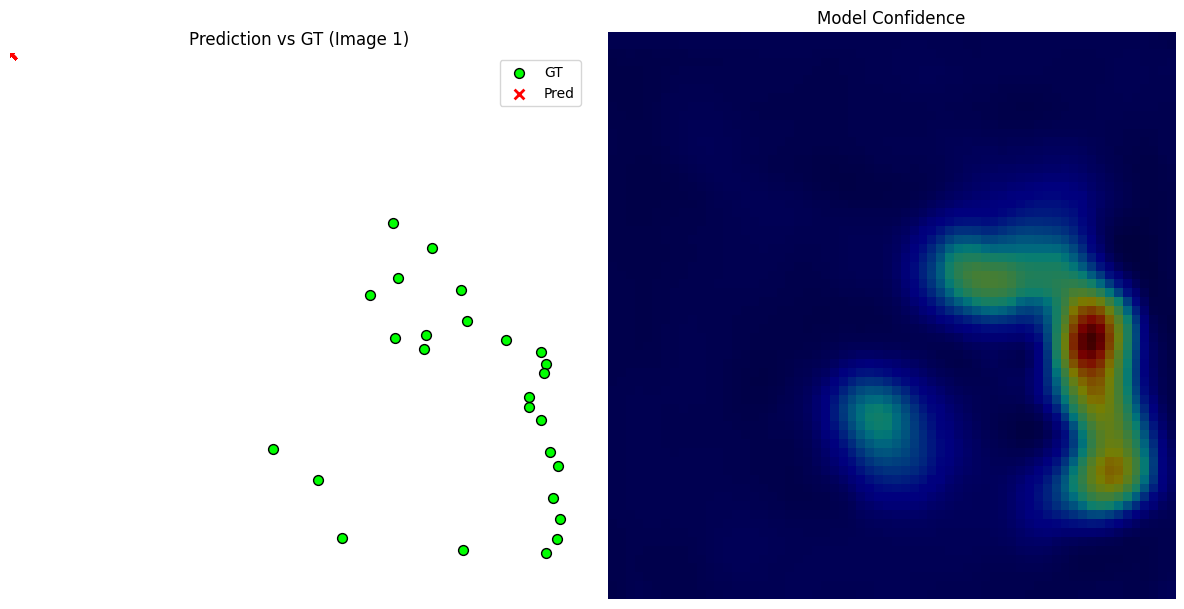

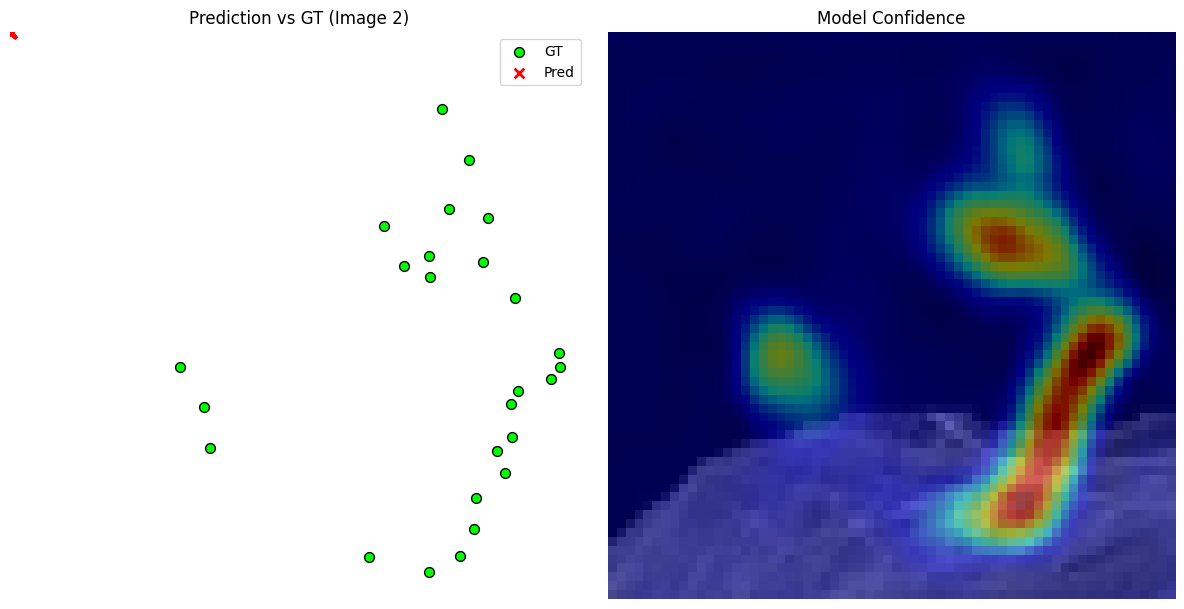

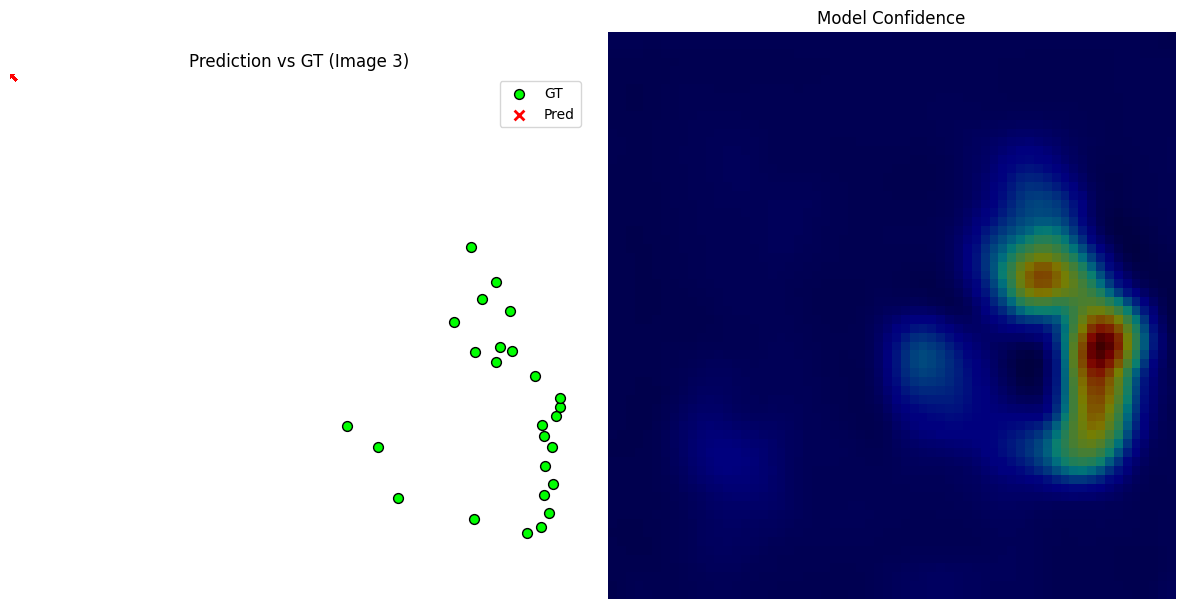

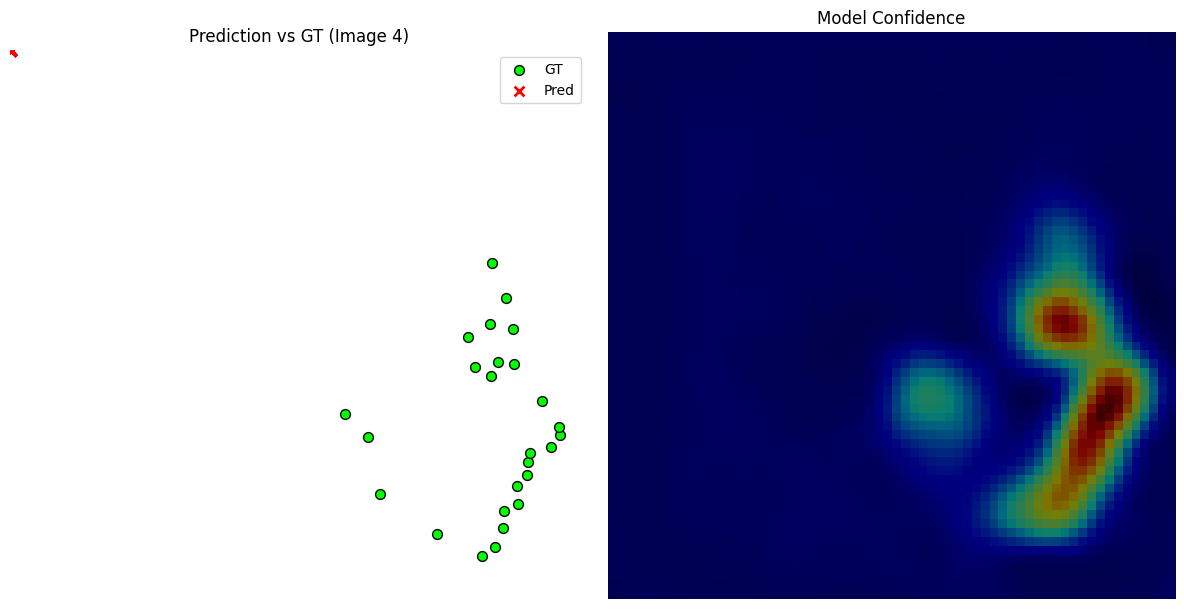

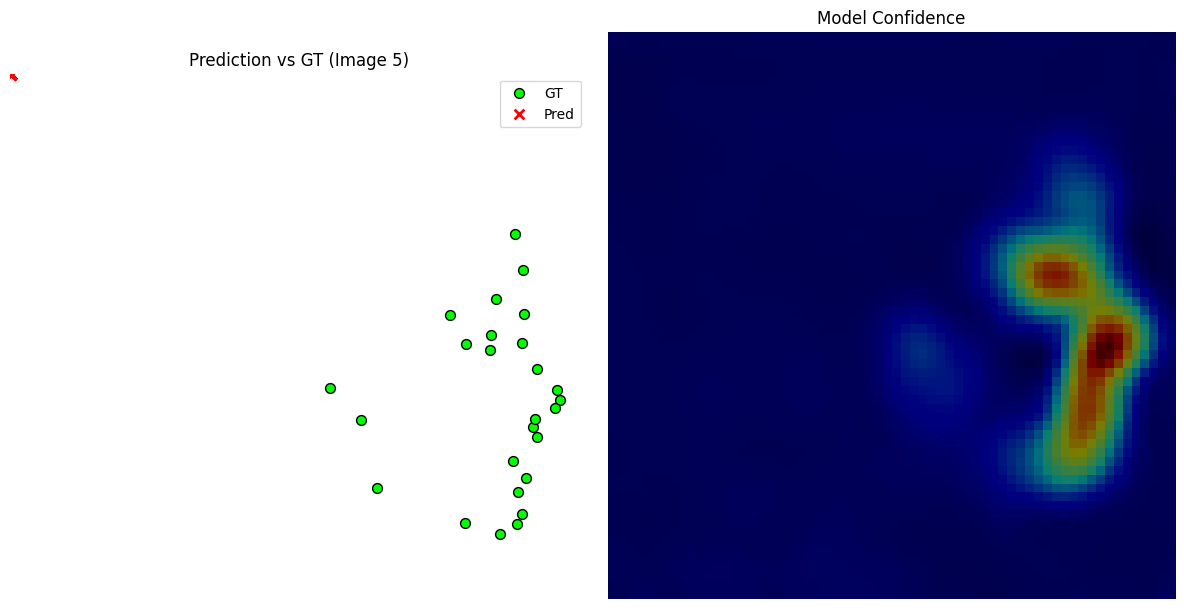

In [17]:
import matplotlib.pyplot as plt
import random
from pathlib import Path

def visualize_validation_sample(count=3):
    """
    Visualizes 'count' random samples from the validation set.
    """
    # --- CONFIGURATION FOR WEIGHTS ---
    # We look in the specific input directory you provided
    INPUT_DIR = Path("/kaggle/input/0-0-2-start")
    
    # Check for weights in likely locations
    possible_paths = [
        INPUT_DIR / "final_kp_aug" / "best_model_fold0.pth", # Subfolder
        INPUT_DIR / "best_model_fold0.pth",                # Root
        Path("final_kp_aug/best_model_fold0.pth")          # Local fallback
    ]
    
    weight_path = None
    for p in possible_paths:
        if p.exists():
            weight_path = p
            break
            
    if weight_path is None:
        print(f"Error: Could not find 'best_model_fold0.pth' in {INPUT_DIR}")
        print(f"Checked: {[str(p) for p in possible_paths]}")
        return

    print(f"Loading weights from: {weight_path}")

    # 1. Load Model
    model = KeypointNet().to(CFG["device"])
    model.load_state_dict(torch.load(weight_path, map_location=CFG["device"]))
    model.eval()

    # 2. Get Validation Data (From Fold 0)
    img_ids = list(images_info.keys())
    groups = np.array([images_info[i]["file_name"].split(".")[0] for i in img_ids])
    gkf = GroupKFold(CFG["folds"])
    _, va_idx = next(gkf.split(img_ids, groups=groups))
    val_ids = [img_ids[i] for i in va_idx]

    # 3. Visualization Loop
    selected_ids = random.sample(val_ids, min(count, len(val_ids)))
    val_ds = KeypointDataset(selected_ids, sigma=2.5, transform=val_aug, cache_data=False)

    for i in range(len(val_ds)):
        img_t, _, vis, kps_norm = val_ds[i]
        
        with torch.no_grad():
            input_tensor = img_t.unsqueeze(0).to(CFG["device"])
            hm_pred = model(input_tensor)
            xy_pred = softargmax_2d(hm_pred)[0].cpu().numpy()

        img_np = img_t.squeeze(0).numpy()
        gt = kps_norm[:, :2].numpy()
        vis_mask = vis.numpy() > 0

        plt.figure(figsize=(12, 6))
        
        # Plot 1: Overlay
        plt.subplot(1, 2, 1)
        plt.imshow(img_np, cmap="gray")
        if vis_mask.sum() > 0:
            plt.scatter(gt[vis_mask, 0] * CFG["img_size"], 
                        gt[vis_mask, 1] * CFG["img_size"],
                        c="lime", s=50, label="GT", marker="o", edgecolors='black')
        plt.scatter(xy_pred[:, 0] * CFG["img_size"], 
                    xy_pred[:, 1] * CFG["img_size"],
                    c="red", s=50, label="Pred", marker="x", linewidths=2)
        plt.legend()
        plt.title(f"Prediction vs GT (Image {i+1})")
        plt.axis("off")

        # Plot 2: Heatmap
        plt.subplot(1, 2, 2)
        hm_sum = hm_pred[0].sum(dim=0).cpu().numpy()
        plt.imshow(img_np, cmap="gray")
        plt.imshow(hm_sum, cmap="jet", alpha=0.5)
        plt.title("Model Confidence")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# --- RUN ---
visualize_validation_sample(count=5)

In [18]:
# ============================================================
# BLOCK 12 — TEST SET EVALUATION (FIXED PATHS)
# ============================================================
import json
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import numpy as np
import cv2
from collections import defaultdict

def evaluate_test_set_with_gt():
    global images_info, anns_by_image, CFG
    
    print("--- STARTING TEST SET EVALUATION ---")
    
    # 1. SETUP PATHS
    TEST_IMG_DIR = Path("/kaggle/input/face-sideview-kp/test")
    TEST_JSON = TEST_IMG_DIR / "_annotations.coco.json"
    
    # Save output to WORKING directory
    SAVE_DIR = Path("/kaggle/working/test_results_gt")
    SAVE_DIR.mkdir(exist_ok=True, parents=True)

    # 2. LOAD TEST ANNOTATIONS
    print(f"Loading Test JSON: {TEST_JSON}")
    with open(TEST_JSON, "r") as f:
        test_coco = json.load(f)

    images_info = {im["id"]: im for im in test_coco["images"]}
    anns_by_image = defaultdict(list)
    for ann in test_coco["annotations"]:
        anns_by_image[ann["image_id"]].append(ann)
        
    original_root = CFG["input_root"] 
    CFG["input_root"] = TEST_IMG_DIR
    
    test_ids = list(images_info.keys())
    print(f"Loaded {len(test_ids)} test images.")

    # 3. FIND MODEL (Updated Logic)
    INPUT_DIR = Path("/kaggle/input/0-0-2-start")
    possible_paths = [
        INPUT_DIR / "final_kp_aug" / "best_model_fold0.pth",
        INPUT_DIR / "best_model_fold0.pth",
        Path("final_kp_aug/best_model_fold0.pth")
    ]
    
    weight_path = None
    for p in possible_paths:
        if p.exists():
            weight_path = p
            break
            
    if weight_path is None:
        print("CRITICAL: No trained model found!")
        print(f"Searched in: {[str(p) for p in possible_paths]}")
        CFG["input_root"] = original_root
        return
        
    print(f"Loading weights: {weight_path}")
    model = KeypointNet().to(CFG["device"])
    model.load_state_dict(torch.load(weight_path, map_location=CFG["device"]))
    model.eval()

    # 4. RUN EVALUATION
    test_ds = KeypointDataset(test_ids, sigma=2.5, cache_data=False)
    print(f"Saving plots to: {SAVE_DIR}")
    
    count = 0
    for i in tqdm(range(len(test_ds)), desc="Processing"):
        try:
            img_t, _, vis, kps_norm = test_ds[i]
            img_id = test_ds.img_ids[i]
            file_name = images_info[img_id]['file_name']

            with torch.no_grad():
                input_tensor = img_t.unsqueeze(0).to(CFG["device"])
                hm_pred = model(input_tensor)
                xy_pred = softargmax_2d(hm_pred)[0].cpu().numpy()

            img_np = img_t.squeeze(0).numpy()
            gt = kps_norm[:, :2].numpy()
            vis_mask = vis.numpy() > 0

            plt.figure(figsize=(10, 10))
            plt.imshow(img_np, cmap="gray")

            if vis_mask.sum() > 0:
                plt.scatter(gt[vis_mask, 0] * CFG["img_size"], 
                            gt[vis_mask, 1] * CFG["img_size"],
                            c="lime", s=50, label="GT", marker="o", edgecolors='black')

            plt.scatter(xy_pred[:, 0] * CFG["img_size"], 
                        xy_pred[:, 1] * CFG["img_size"],
                        c="red", s=50, label="Pred", marker="x", linewidths=2)

            plt.legend()
            plt.title(f"Test Image: {file_name}")
            plt.axis("off")

            plt.savefig(SAVE_DIR / f"test_{file_name}.png", bbox_inches='tight')
            plt.close()
            count += 1
            
        except Exception as e:
            print(f"Skipping {i}: {e}")
            continue

    CFG["input_root"] = original_root
    print(f"Done! Saved {count} images.")

# --- RUN ---
evaluate_test_set_with_gt()

--- STARTING TEST SET EVALUATION ---
Loading Test JSON: /kaggle/input/face-sideview-kp/test/_annotations.coco.json
Loaded 82 test images.
Loading weights: /kaggle/input/0-0-2-start/final_kp_aug/best_model_fold0.pth
Saving plots to: /kaggle/working/test_results_gt


Processing:   0%|          | 0/82 [00:00<?, ?it/s]

Done! Saved 82 images.


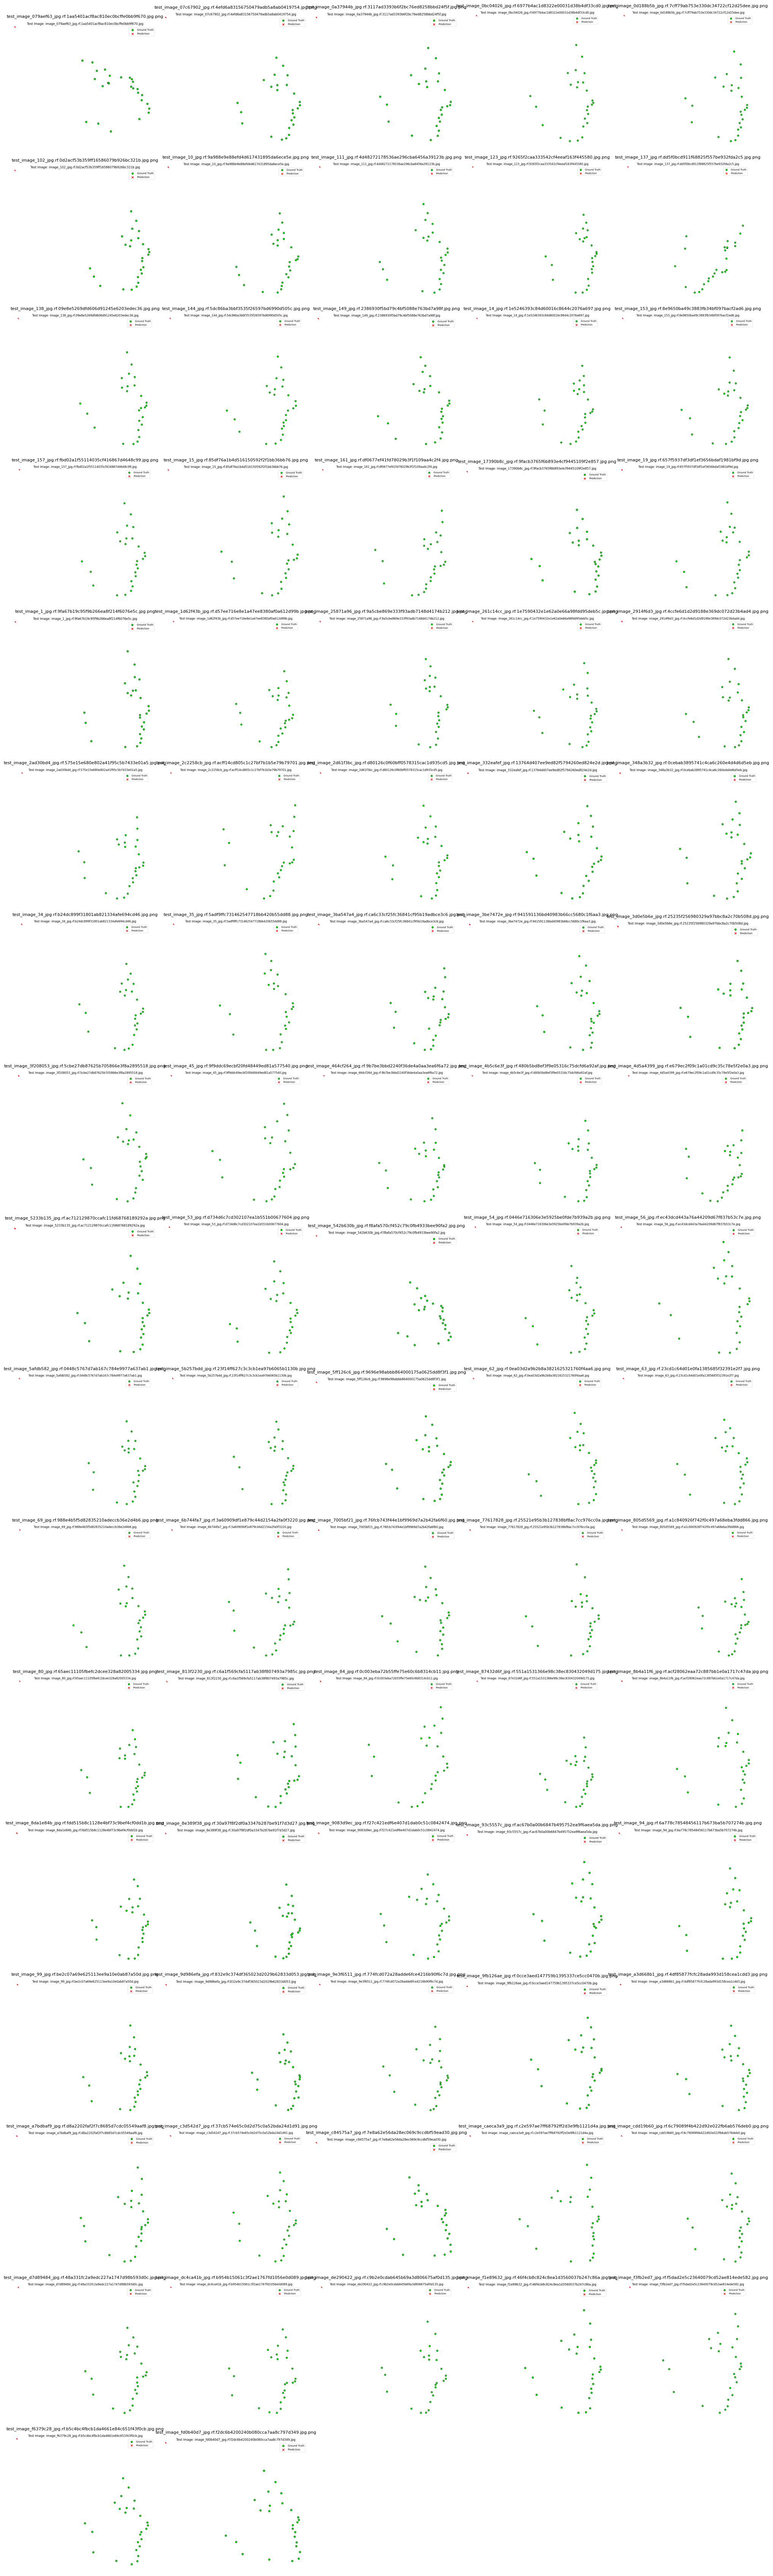

In [26]:
import os
import math
import cv2
import matplotlib.pyplot as plt

IMG_DIR = "/kaggle/working/test_results_gt"

# Collect image paths
img_files = [
    os.path.join(IMG_DIR, f)
    for f in sorted(os.listdir(IMG_DIR))
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

assert len(img_files) > 0, "No images found in the folder"

# Grid configuration
N = len(img_files)
cols = 5  # you can change this
rows = math.ceil(N / cols)

plt.figure(figsize=(cols * 4, rows * 4))

for i, img_path in enumerate(img_files):
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


✅ Loading model from: /kaggle/input/0-0-2-start/final_kp_aug/best_model_fold0.pth
🔍 Displaying 20 samples...


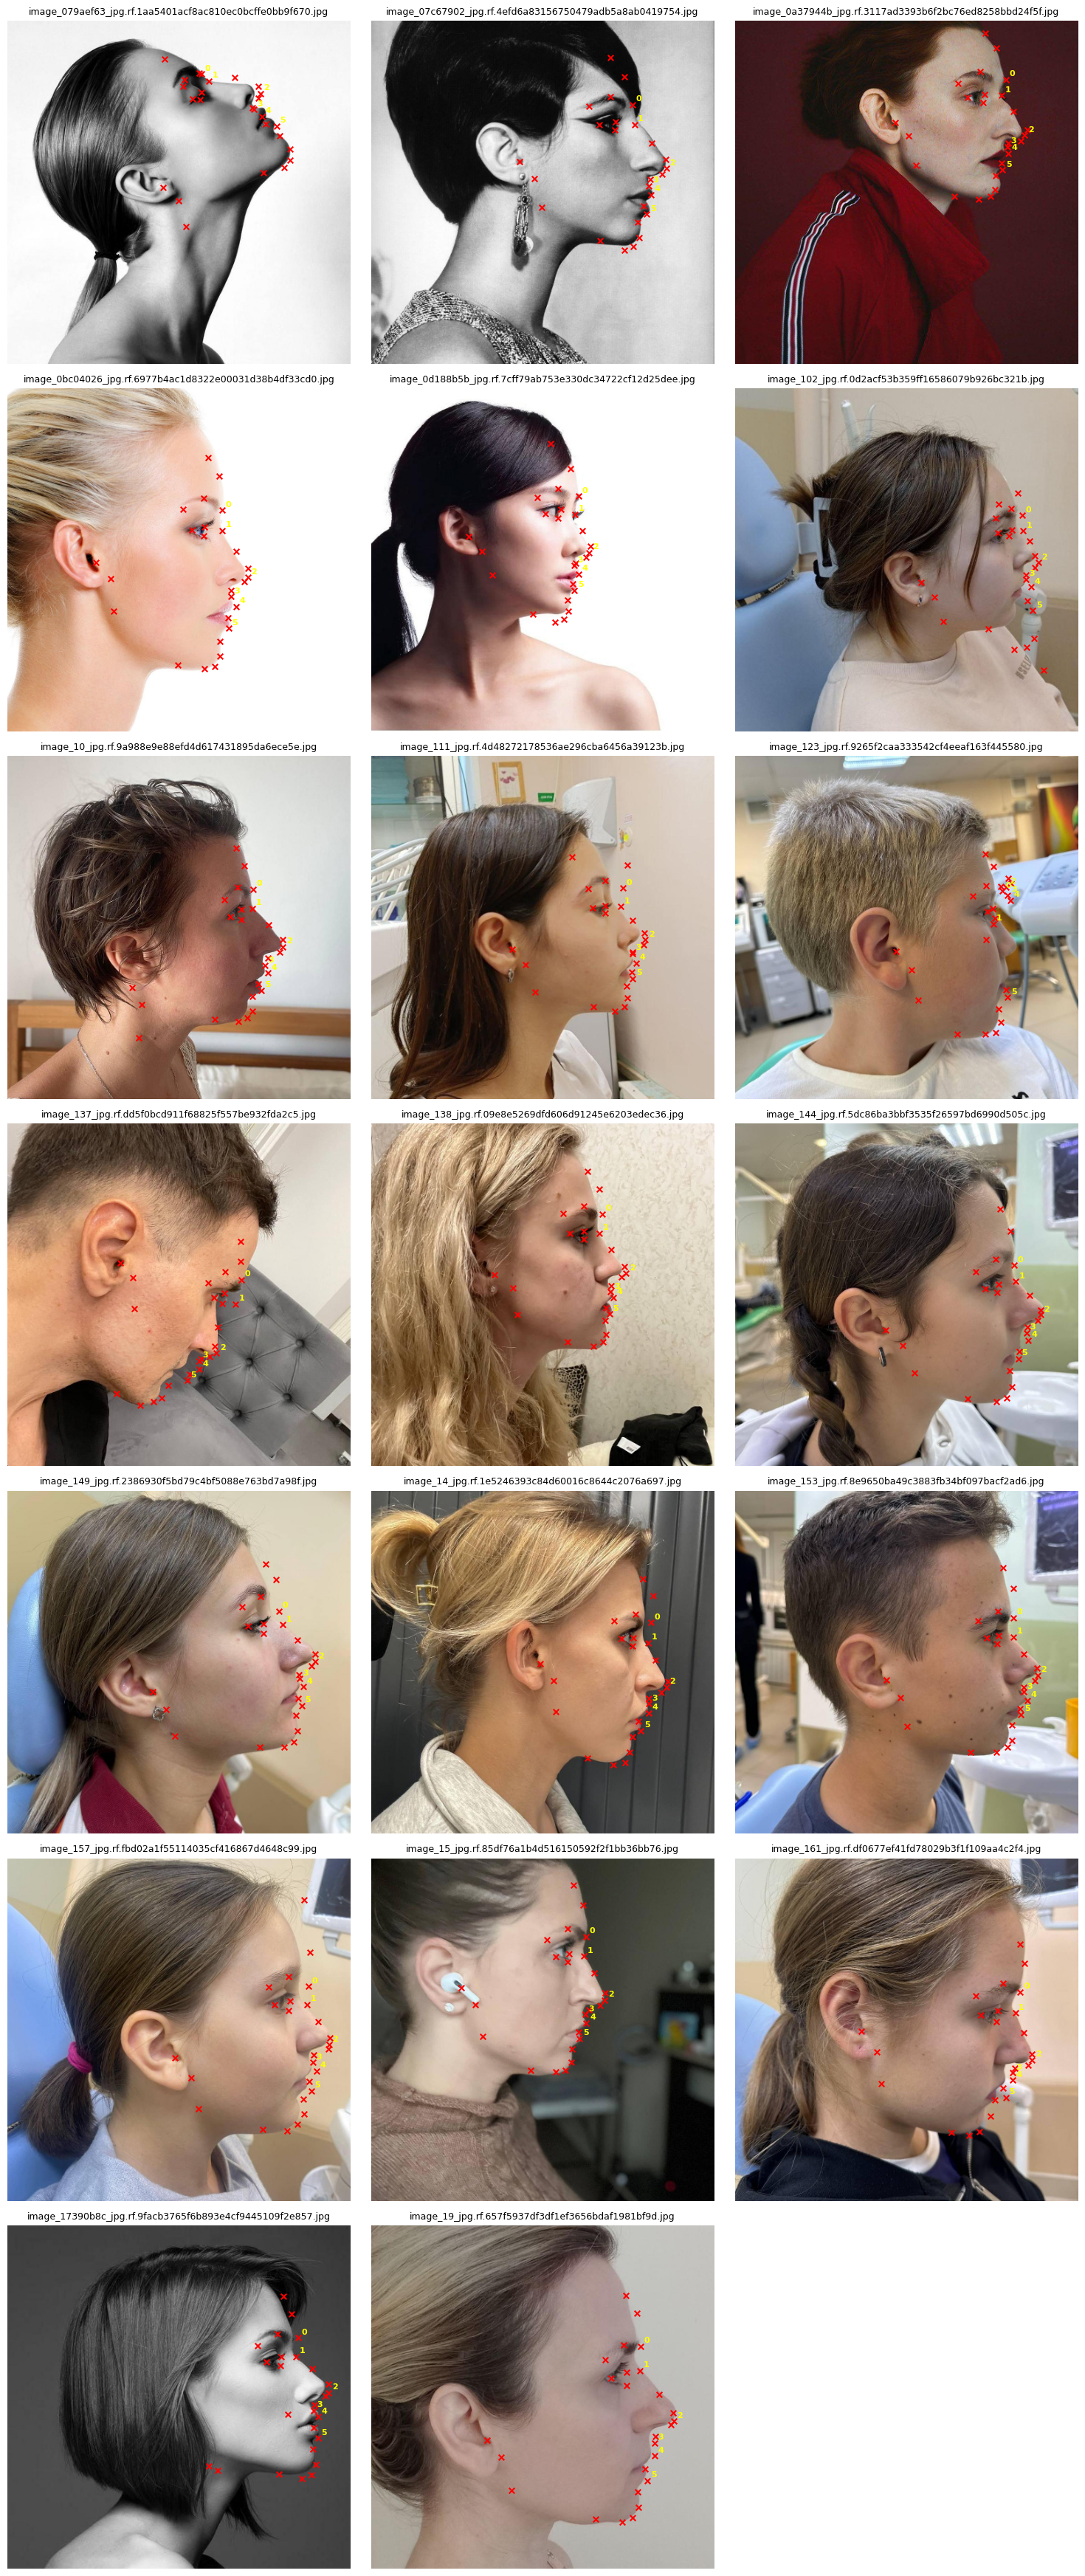

In [29]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
from pathlib import Path
from torchvision.models import mobilenet_v3_large
import torch.nn.functional as F

# --- CONFIGURATION ---
CFG = {
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "img_size": 512,
    "num_kpts": 26,  # UPDATED: Weights dictate 26 keypoints
    "test_dir": Path("/kaggle/input/face-sideview-kp/test"),
    "weights_dir": Path("/kaggle/input/0-0-2-start")
}

# --- 1. MODEL ARCHITECTURE (MATCHING SAVED WEIGHTS) ---
class KeypointNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Load Standard Backbone
        self.backbone = mobilenet_v3_large(weights=None).features
        
        # FIX 1: Change first layer to accept 1 Channel (Grayscale)
        # Saved weight: [16, 1, 3, 3] -> Input=1
        self.backbone[0][0] = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, bias=False)
        
        # FIX 2: Head uses 3x3 Convs and Bias=True
        self.head = nn.Module()
        self.head.net = nn.Sequential(
            # Layer 0: 960->256, 3x3 Conv, Bias=True
            nn.Conv2d(960, 256, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Upsample 1
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            # Layer 4: 256->128, 3x3 Conv, Bias=True
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            # Upsample 2
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            # Layer 8: 128->26 Keypoints
            nn.Conv2d(128, CFG["num_kpts"], kernel_size=1, bias=True)
        )
    
    def forward(self, x):
        # x is [B, 1, 512, 512]
        x = self.backbone(x)
        x = self.head.net(x)
        return x

def softargmax_2d(heatmaps, beta=100.0):
    B, N, H, W = heatmaps.shape
    hm_flat = heatmaps.view(B, N, -1)
    weights = F.softmax(beta * hm_flat, dim=-1)
    
    y, x = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    x = x.to(heatmaps.device).float() / (W - 1)
    y = y.to(heatmaps.device).float() / (H - 1)
    
    out_x = torch.sum(weights * x.view(-1), dim=-1)
    out_y = torch.sum(weights * y.view(-1), dim=-1)
    return torch.stack([out_x, out_y], dim=-1)

# --- 2. PRE-PROCESSING FUNCTION ---
def preprocess_image(img_path):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: return None, None
    
    # Resize to 512x512
    img_resized = cv2.resize(img_bgr, (CFG["img_size"], CFG["img_size"]))
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    # Normalize & Shape: [1, 1, 512, 512]
    img_t = torch.from_numpy(img_gray).float().unsqueeze(0).unsqueeze(0) / 255.0
    return img_t.to(CFG["device"]), img_resized

# --- 3. VISUALIZATION LOGIC ---
def visualize_predictions(num_images=6):
    # Search for weights
    weight_path = None
    search_paths = [
        CFG["weights_dir"] / "final_kp_aug" / "best_model_fold0.pth",
        CFG["weights_dir"] / "best_model_fold0.pth",
        Path("best_model_fold0.pth")
    ]
    
    for p in search_paths:
        if p.exists():
            weight_path = p
            break
            
    if not weight_path:
        print(f"❌ Error: Weights not found. Checked: {[str(p) for p in search_paths]}")
        return

    print(f"✅ Loading model from: {weight_path}")
    model = KeypointNet().to(CFG["device"])
    
    # Load weights with strict=True now that we matched architecture
    model.load_state_dict(torch.load(weight_path, map_location=CFG["device"]), strict=True)
    model.eval()
    
    # Get Images
    test_files = sorted(list(CFG["test_dir"].glob("*.jpg")) + list(CFG["test_dir"].glob("*.png")))
    if not test_files:
        print("❌ No images found in test folder.")
        return

    print(f"🔍 Displaying {num_images} samples...")
    
    # Plot
    cols = 3
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(cols * 5, rows * 5))
    
    for i, img_file in enumerate(test_files[:num_images]):
        input_t, img_display = preprocess_image(img_file)
        if input_t is None: continue
        
        with torch.no_grad():
            hm = model(input_t)
            xy = softargmax_2d(hm)[0].cpu().numpy() # [26, 2]
            
        # Scale to image size
        h, w = img_display.shape[:2]
        xy[:, 0] *= w
        xy[:, 1] *= h
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
        
        # Plot all 26 points
        plt.scatter(xy[:, 0], xy[:, 1], c='red', s=30, marker='x', label='Pred')
        
        # Label first few points to avoid clutter
        for k in range(len(xy)):
            if k in [25,8]: 
                plt.text(xy[k, 0]+5, xy[k, 1]-5, str(k), color='yellow', fontsize=8, fontweight='bold')
            
        plt.title(img_file.name, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN ---
visualize_predictions(num_images=20)